# 1. Import các thư viện cần thiết và cấu hình đồ họa

In [2]:
%pip install statsmodels


   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   ------ --------------------------------- 1.8/11.3 MB 6.7 MB/s eta 0:00:02
   ------- -------------------------------- 2.1/11.3 MB 5.9 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/11.3 MB 5.1 MB/s eta 0:00:02
   ------------------- -------------------- 5.5/11.3 MB 6.0 MB/s eta 0:00:01
   ------------------------- -------------- 7.1/11.3 MB 6.2 MB/s eta 0:00:01
   ------------------------------ --------- 8.7/11.3 MB 6.4 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.3 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 5.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.7 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.7 MB 9.5 MB/s eta 0:00:04
   -- ------------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ==============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Thiết lập cấu hình đồ họa chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# 2. Cấu hình đường dẫn dữ liệu

In [14]:
DATA_DIR = "data/raw"
TRAIN_PATH = os.path.join(DATA_DIR, "Train/Monthly-train.csv")
TEST_PATH = os.path.join(DATA_DIR, "Test/Monthly-test.csv")
INFO_PATH = os.path.join(DATA_DIR, "M4-info.csv")

print(f"Đường dẫn train: {TRAIN_PATH}")
print(f"Đường dẫn test: {TEST_PATH}")
print(f"Đường dẫn info: {INFO_PATH}")


Đường dẫn train: data/raw/Train/Monthly-train.csv
Đường dẫn test: data/raw/Test/Monthly-test.csv
Đường dẫn info: data/raw/M4-info.csv


# 3. Đọc và khám phá dữ liệu thô (Wide Format)

In [ ]:
print("Đang tải dữ liệu thô...")
# Chỉ đọc 500 dòng đầu để phân tích nhanh và tránh tràn RAM
train_wide = pd.read_csv(TRAIN_PATH, nrows=500)
test_wide = pd.read_csv(TEST_PATH, nrows=500)
info_df = pd.read_csv(INFO_PATH)

# Đổi tên cột đầu tiên thành unique_id
train_wide.rename(columns={train_wide.columns[0]: 'unique_id'}, inplace=True)
test_wide.rename(columns={test_wide.columns[0]: 'unique_id'}, inplace=True)

print("\n--- THÔNG TIN TẬP TRAIN (WIDE FORMAT) ---")
print(f"Kích thước tập thô (chỉ đọc 500 dòng): {train_wide.shape}")
print("5 dòng đầu tiên:")
print(train_wide.head())

Đang tải dữ liệu thô...

--- THÔNG TIN TẬP TRAIN (WIDE FORMAT) ---
Kích thước tập thô (chỉ đọc 500 dòng): (500, 2795)
5 dòng đầu tiên:
  unique_id      V2      V3      V4      V5      V6      V7      V8      V9  \
0        M1  8000.0  8350.0  8570.0  7700.0  7080.0  6520.0  6070.0  6650.0   
1        M2  2440.0  2490.0  2710.0  2290.0  1960.0  1990.0  1960.0  2530.0   
2        M3  2670.0  2590.0  2784.0  2816.0  2888.0  2906.0  2839.0  2860.0   
3        M4  7264.0  7215.0  7022.0  7040.0  6966.0  6984.0  7025.0  7082.0   
4        M5  4210.0  4290.0  4250.0  4320.0  4320.0  4330.0  4320.0  4260.0   

      V10  ...  V2786  V2787  V2788  V2789  V2790  V2791  V2792  V2793  V2794  \
0  6830.0  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
1  2640.0  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
2  2798.0  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
3  6956.0  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN   

# 4. Phân tích độ dài các chuỗi thời gian (Series Length)


--- THỐNG KÊ ĐỘ DÀI CÁC CHUỎI THỜI GIAN ---
count     500.000000
mean      317.686000
std       231.735647
min        61.000000
25%       138.000000
50%       238.500000
75%       421.500000
max      1230.000000
Name: length, dtype: float64


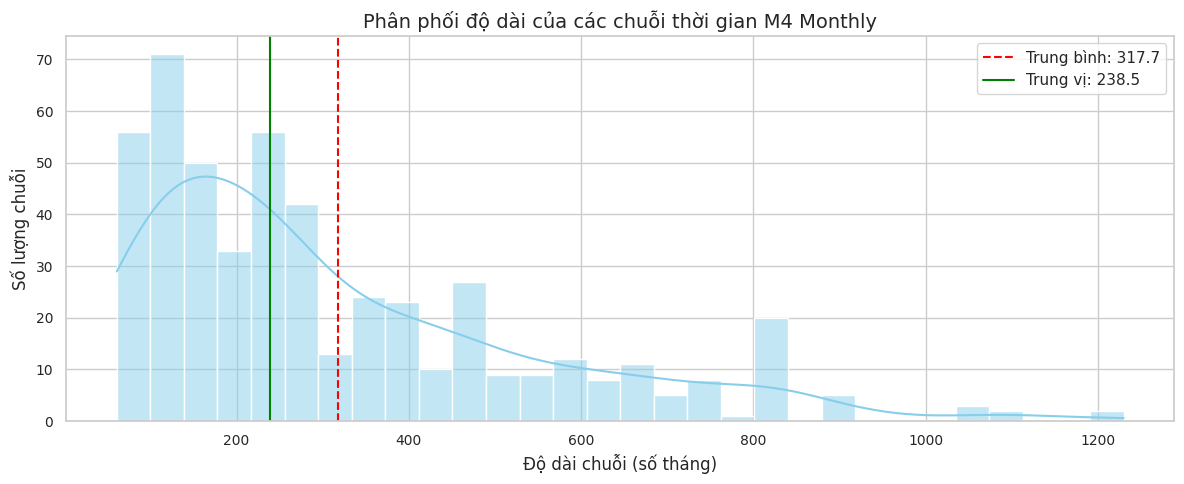

In [ ]:
# Tính toán độ dài thực tế của từng chuỗi thời gian (bằng cách loại bỏ NaN ở cuối mỗi hàng)
series_lengths = []
for idx, row in train_wide.set_index('unique_id').iterrows():
    # Loại bỏ các giá trị NaN để đếm số bước thời gian thực tế của chuỗi này
    actual_series = row.dropna()
    series_lengths.append({
        'unique_id': idx,
        'length': len(actual_series)
    })

lengths_df = pd.DataFrame(series_lengths)

# Thống kê mô tả về độ dài
print("\n--- THỐNG KÊ ĐỘ DÀI CÁC CHUỎI THỜI GIAN ---")
print(lengths_df['length'].describe())

# Vẽ biểu đồ phân phối độ dài chuỗi
plt.figure(figsize=(12, 5))
sns.histplot(lengths_df['length'], bins=30, kde=True, color='skyblue')
plt.axvline(lengths_df['length'].mean(), color='red', linestyle='--', label=f"Trung bình: {lengths_df['length'].mean():.1f}")
plt.axvline(lengths_df['length'].median(), color='green', linestyle='-', label=f"Trung vị: {lengths_df['length'].median():.1f}")
plt.title("Phân phối độ dài của các chuỗi thời gian M4 Monthly")
plt.xlabel("Độ dài chuỗi (số tháng)")
plt.ylabel("Số lượng chuỗi")
plt.legend()
plt.tight_layout()
plt.show()

# 5. Khám phá tệp thông tin M4-info.csv


--- THÔNG TIN VỀ CÁC CHUỖI MONTHLY TRONG M4-INFO ---
Tổng số chuỗi Monthly trong bộ dữ liệu gốc: 48000

Phân phối theo Lĩnh vực (Category):
category
Finance        10987
Micro          10975
Industry       10017
Macro          10016
Demographic     5728
Other            277
Name: count, dtype: int64


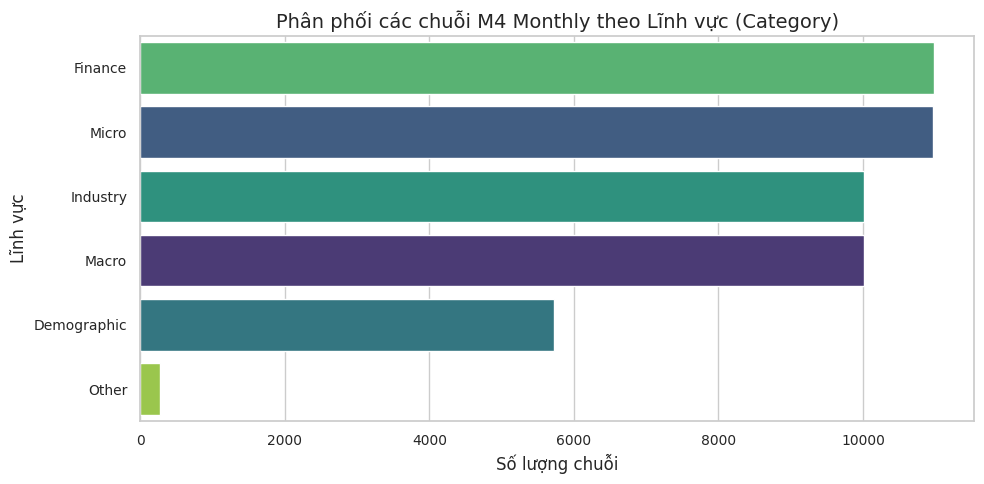

In [13]:
monthly_info = info_df[info_df['SP'] == 'Monthly']

print("\n--- THÔNG TIN VỀ CÁC CHUỖI MONTHLY TRONG M4-INFO ---")
print(f"Tổng số chuỗi Monthly trong bộ dữ liệu gốc: {len(monthly_info)}")
print("\nPhân phối theo Lĩnh vực (Category):")
print(monthly_info['category'].value_counts())

# Vẽ biểu đồ cột phân phối lĩnh vực
plt.figure(figsize=(10, 5))
category_col = 'category'
sns.countplot(data=monthly_info, y=category_col, hue=category_col, order=monthly_info[category_col].value_counts().index, palette='viridis', legend=False)
plt.title("Phân phối các chuỗi M4 Monthly theo Lĩnh vực (Category)")
plt.xlabel("Số lượng chuỗi")
plt.ylabel("Lĩnh vực")
plt.tight_layout()
plt.show()

# 6. Trực quan hóa một số chuỗi thời gian ngẫu nhiên

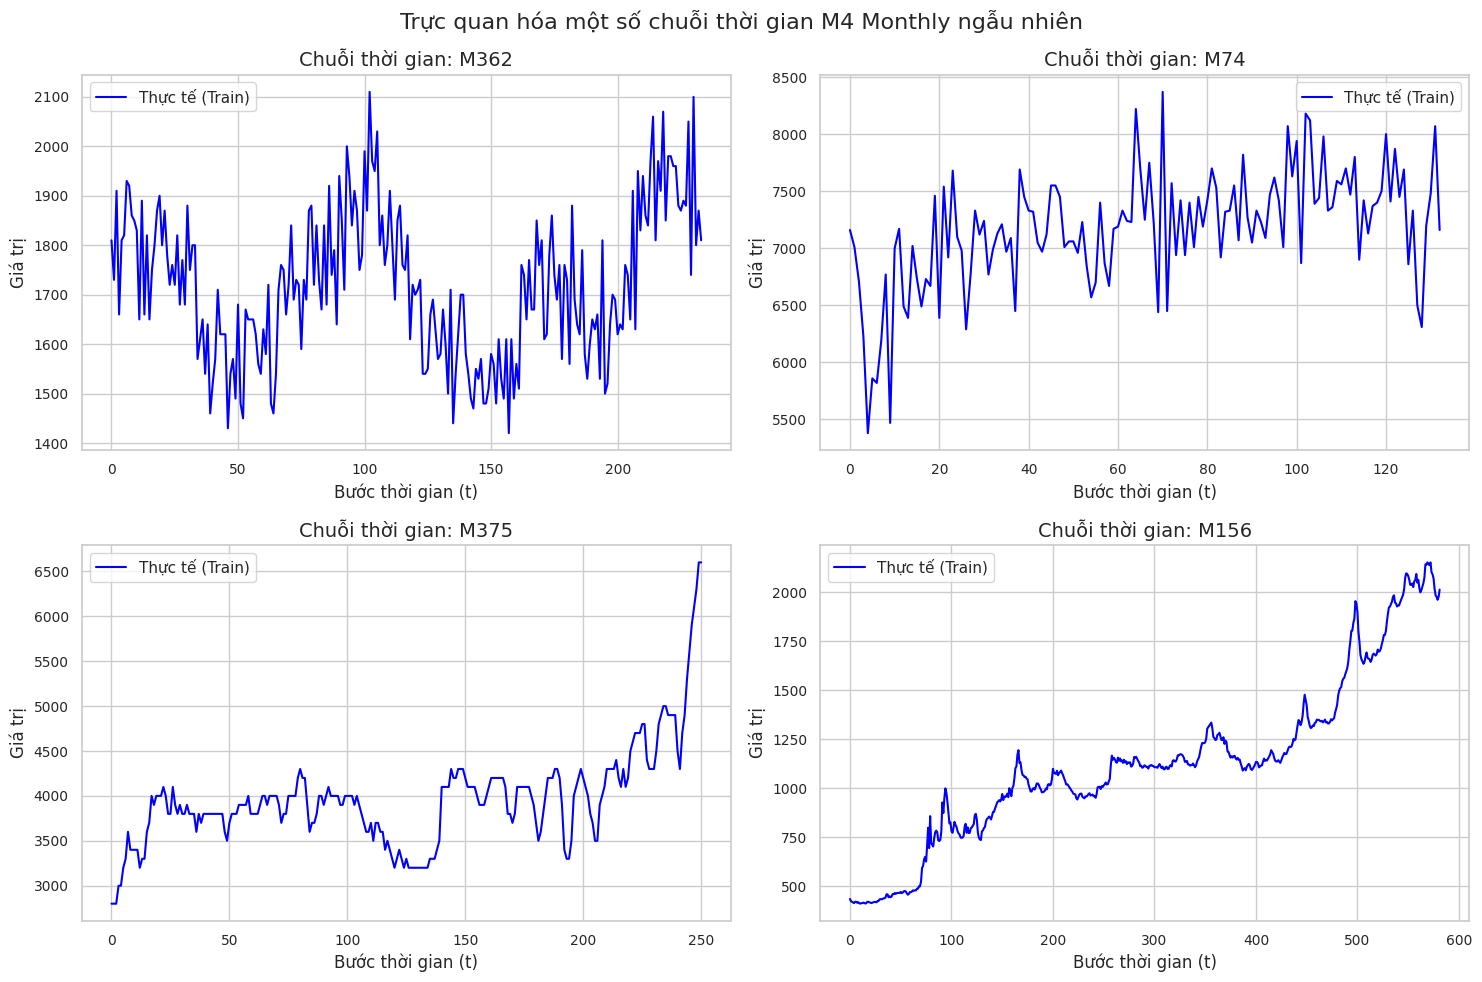

In [ ]:
# Chọn ngẫu nhiên 4 chuỗi từ tập train_wide để vẽ biểu đồ
np.random.seed(42)  # Đảm bảo kết quả hiển thị giống nhau mỗi lần chạy
random_ids = np.random.choice(train_wide['unique_id'].unique(), size=4, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, uid in enumerate(random_ids):
    # Trích xuất dữ liệu chuỗi và loại bỏ NaN
    series_data = train_wide[train_wide['unique_id'] == uid].iloc[0, 1:].dropna().values

    axes[i].plot(series_data, label='Thực tế (Train)', color='blue')
    axes[i].set_title(f"Chuỗi thời gian: {uid}")
    axes[i].set_xlabel("Bước thời gian (t)")
    axes[i].set_ylabel("Giá trị")
    axes[i].legend()

plt.suptitle("Trực quan hóa một số chuỗi thời gian M4 Monthly ngẫu nhiên", fontsize=16)
plt.tight_layout()
plt.show()


# 7. Phân tích tính Tự tương quan (Autocorrelation - ACF / PACF)

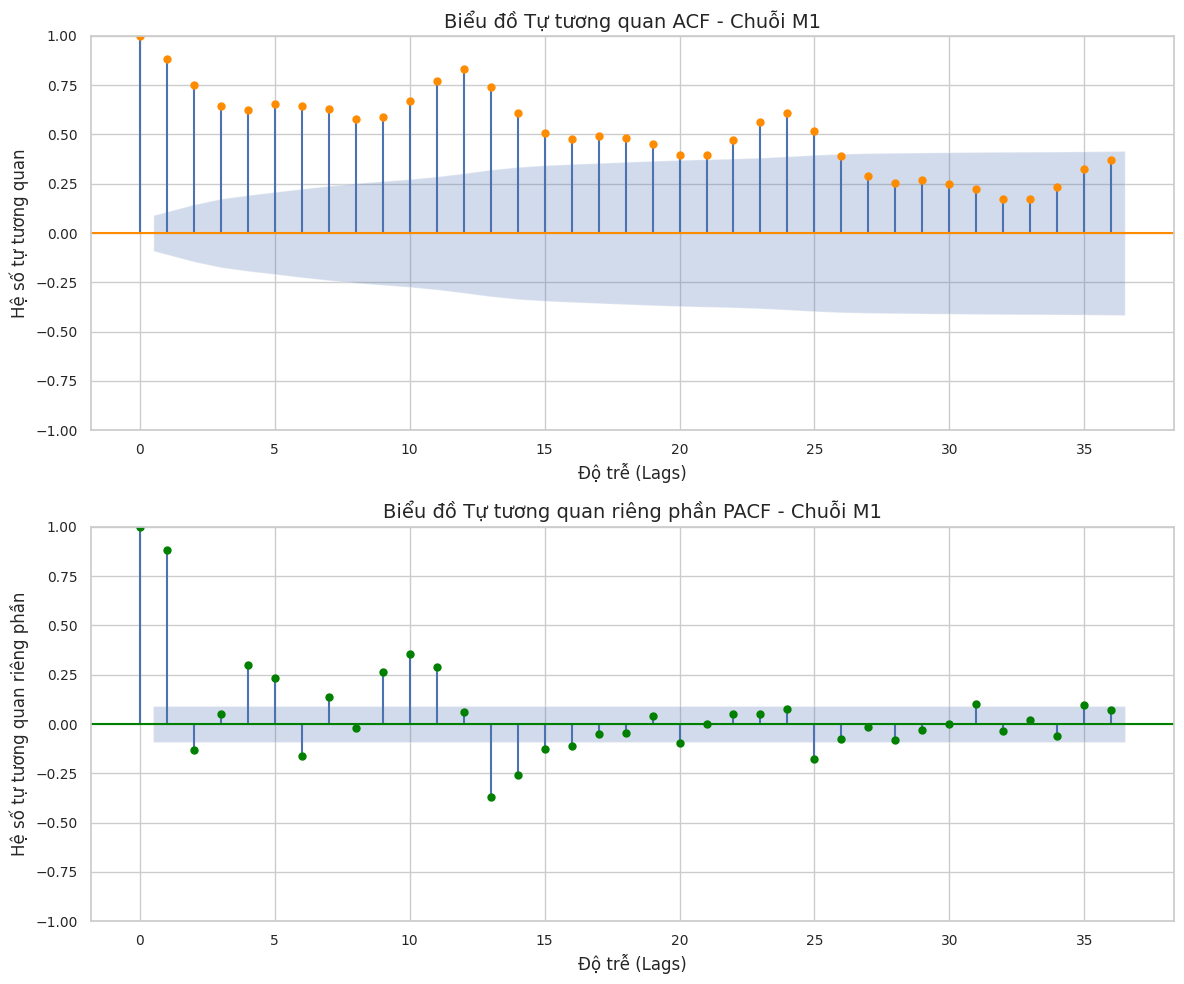

In [ ]:
# Việc phân tích ACF/PACF giúp xác định chu kỳ mùa vụ và lựa chọn Lag Features khoa học hơn.
# Chúng ta sẽ phân tích trên một chuỗi cụ thể (ví dụ: chuỗi đầu tiên M1)
target_uid = 'M1'
m1_series = train_wide[train_wide['unique_id'] == target_uid].iloc[0, 1:].dropna().astype(float).values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Vẽ biểu đồ ACF (Autocorrelation Function)
plot_acf(m1_series, lags=36, ax=ax1, color='darkorange')
ax1.set_title(f"Biểu đồ Tự tương quan ACF - Chuỗi {target_uid}")
ax1.set_xlabel("Độ trễ (Lags)")
ax1.set_ylabel("Hệ số tự tương quan")

# Vẽ biểu đồ PACF (Partial Autocorrelation Function)
plot_pacf(m1_series, lags=36, ax=ax2, color='green')
ax2.set_title(f"Biểu đồ Tự tương quan riêng phần PACF - Chuỗi {target_uid}")
ax2.set_xlabel("Độ trễ (Lags)")
ax2.set_ylabel("Hệ số tự tương quan riêng phần")

plt.tight_layout()
plt.show()


# 8. Nhận xét và Đề xuất Hướng xử lý Dữ liệu (Dành cho báo cáo kỹ thuật)

In [ ]:
print("""
==============================================================================
KẾT LUẬN & ĐỀ XUẤT CHO BƯỚC FEATURE ENGINEERING (src/features.py):
==============================================================================
1. Độ dài các chuỗi không đồng đều:
   - Đề xuất: Khi chuyển đổi dữ liệu từ Wide sang Long trong data_loader.py,
     bắt buộc phải sử dụng .dropna() để loại bỏ các ô NaN dư thừa ở đuôi các chuỗi ngắn.

2. Đặc trưng trễ (Lag Features):
   - Nhìn vào biểu đồ ACF/PACF: Hệ số tự tương quan thường rất cao ở các độ trễ gần (1, 2, 3)
     và có sự lặp lại chu kỳ ở độ trễ 12 (đối với dữ liệu Monthly).
   - Đề xuất: Tạo các đặc trưng lag_1, lag_2, lag_3 (ngắn hạn) và lag_12 (mùa vụ hàng năm).

3. Thống kê trượt (Rolling Statistics):
   - Đề xuất: Sử dụng các cửa sổ trượt kích thước 3, 6, 12 tháng (rolling_mean_3, rolling_std_3, etc.)
     để giúp mô hình nắm bắt xu hướng trung bình và độ biến động cục bộ của thị trường.
     CHÚ Ý: Phải thực hiện shift(1) trước khi tính toán để chống rò rỉ dữ liệu (data leakage).

4. Tính mùa vụ (Date Features):
   - Do dữ liệu gốc bị ẩn danh hóa và không có ngày tháng thật, việc giả lập cột 'ds' từ '1900-01-01'
     là hợp lý. Từ đó, trích xuất các đặc trưng lịch như 'month', 'quarter', 'is_quarter_end'
     để mô hình Gradient Boosting nhận diện tính chu kỳ năm cực tốt.
==============================================================================
""")



KẾT LUẬN & ĐỀ XUẤT CHO BƯỚC FEATURE ENGINEERING (src/features.py):
1. Độ dài các chuỗi không đồng đều: 
   - Đề xuất: Khi chuyển đổi dữ liệu từ Wide sang Long trong data_loader.py, 
     bắt buộc phải sử dụng .dropna() để loại bỏ các ô NaN dư thừa ở đuôi các chuỗi ngắn.

2. Đặc trưng trễ (Lag Features):
   - Nhìn vào biểu đồ ACF/PACF: Hệ số tự tương quan thường rất cao ở các độ trễ gần (1, 2, 3) 
     và có sự lặp lại chu kỳ ở độ trễ 12 (đối với dữ liệu Monthly).
   - Đề xuất: Tạo các đặc trưng lag_1, lag_2, lag_3 (ngắn hạn) và lag_12 (mùa vụ hàng năm).

3. Thống kê trượt (Rolling Statistics):
   - Đề xuất: Sử dụng các cửa sổ trượt kích thước 3, 6, 12 tháng (rolling_mean_3, rolling_std_3, etc.) 
     để giúp mô hình nắm bắt xu hướng trung bình và độ biến động cục bộ của thị trường.
     CHÚ Ý: Phải thực hiện shift(1) trước khi tính toán để chống rò rỉ dữ liệu (data leakage).

4. Tính mùa vụ (Date Features):
   - Do dữ liệu gốc bị ẩn danh hóa và không có ngày tháng thật, việc giả lập c